In [1]:
import torch
from torch.utils.data import DataLoader, Dataset
from torch import nn
from torch.optim import Adam
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import jieba  
import pandas as pd
# Check for available CUDA device(s)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Define the hyper parameter
BATCH_SIZE = 64
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
OUTPUT_DIM = 1
EPOCHS = 20

In [3]:
# To test the csv import correctly
import pandas as pd

df = pd.read_csv('goemotions_1.csv')

print(df.head())

                                                text       id  \
0                                    That game hurt.  eew5j0j   
1   >sexuality shouldn’t be a grouping category I...  eemcysk   
2     You do right, if you don't care then fuck 'em!  ed2mah1   
3                                 Man I love reddit.  eeibobj   
4  [NAME] was nowhere near them, he was by the Fa...  eda6yn6   

                author            subreddit    link_id   parent_id  \
0                Brdd9                  nrl  t3_ajis4z  t1_eew18eq   
1          TheGreen888     unpopularopinion  t3_ai4q37   t3_ai4q37   
2             Labalool          confessions  t3_abru74  t1_ed2m7g7   
3        MrsRobertshaw             facepalm  t3_ahulml   t3_ahulml   
4  American_Fascist713  starwarsspeculation  t3_ackt2f  t1_eda65q2   

    created_utc  rater_id  example_very_unclear  admiration  ...  love  \
0  1.548381e+09         1                 False           0  ...     0   
1  1.548084e+09        37               

In [4]:
# Extract some column
columns_data = df.loc[:, ['text', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']]

print(columns_data)

                                                    text  admiration  \
0                                        That game hurt.           0   
1       >sexuality shouldn’t be a grouping category I...           0   
2         You do right, if you don't care then fuck 'em!           0   
3                                     Man I love reddit.           0   
4      [NAME] was nowhere near them, he was by the Fa...           0   
...                                                  ...         ...   
69995        It's about fucking time, hope this is real.           0   
69996  This is great! Can anyone make a request with ...           1   
69997  I’m sorry. Can you please explain what are the...           0   
69998                                No but it should be           0   
69999  This is so cruel. I literally feel physically ...           0   

       amusement  anger  annoyance  approval  caring  confusion  curiosity  \
0              0      0          0         0       0     

In [5]:
print(len(columns_data))

70000


In [6]:
import pandas as pd
from torch.utils.data import Dataset

# Define a dataset class for which dataset comes from google
class GoogleDataset(Dataset):
    def __init__(self, file_path):
        # Initialize an empty list to store data
        self.data = []

        # Read the first csv file
        df = pd.read_csv(file_path[0], encoding="utf-8")

        # Acquie the column
        columns_data = df.loc[:, ['text', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 
                                  'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 
                                  'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 
                                  'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 
                                  'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 
                                  'neutral']]

        # Get the emotion column
        emotion_columns = columns_data.columns[1:]

        columns_data[emotion_columns] = columns_data[emotion_columns].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

        # Deal with dataset
        for index, row in columns_data.iterrows():
            text = row['text']
            if text == 'text':  # 跳过头部行
                continue

            # Transfer to list
            emotions = row[emotion_columns].tolist()

            # Define a new column named 'label'
            label = next((i for i, emotion in enumerate(emotions) if emotion == 1), -1)

            # Append to list
            self.data.append((label, text))

        # Do same process for the second 
        if len(file_path) > 1:
            data = pd.read_csv(file_path[1], skiprows=1, sep=',', names=['text', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 
                                   'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 
                                   'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 
                                   'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 
                                   'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 
                                   'neutral'], encoding='utf-8')
            emotion_columns_1 = data.columns[1:]

            # Transfer to corresponding label
            data[emotion_columns_1] = data[emotion_columns_1].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

            for index, row in data.iterrows():
                text1 = row['text']
                emotions1 = row[emotion_columns_1].tolist()

                label1 = next((i for i, emotion in enumerate(emotions1) if emotion == 1), -1)

                self.data.append((label1, text1))

        print(self.data[:10])
        print(len(self.data))

    # Return the length of the dataset
    def __len__(self):
        return len(self.data)

    # Return the item at the given index
    def __getitem__(self, idx):
        label, text = self.data[idx]
        return label, text


# train_data = GoogleDataset(["goemotions_1.csv"])
train_data = GoogleDataset(["goemotions_1.csv", "goemotions_2.csv"])  # Assuming there’s a train file
test_data = GoogleDataset(["goemotions_3.csv"])  # Assuming there’s a test file

[(25, 'That game hurt.'), (-1, ' >sexuality shouldn’t be a grouping category It makes you different from othet ppl so imo it fits the definition of "grouping" '), (27, "You do right, if you don't care then fuck 'em!"), (18, 'Man I love reddit.'), (27, '[NAME] was nowhere near them, he was by the Falcon. '), (15, 'Right? Considering it’s such an important document, I should know the damned thing backwards and forwards... thanks again for the help!'), (10, "He isn't as big, but he's still quite popular. I've heard the same thing about his content. Never watched him much."), (1, "That's crazy; I went to a super [RELIGION] high school and I think I can remember 2 girls the entire 4 years that became teen moms."), (1, "that's adorable asf"), (1, '"Sponge Blurb Pubs Quaw Haha GURR ha AAa!" finale is too real')]
140000
[(9, "Worst ending ever! I won't spoil it but this one sucked worse than the avengers last movie!"), (13, 'Happy cake day u/sneakpeekbot!'), (6, 'Was he rejected because of his

In [7]:
import pandas as pd
from torch.utils.data import Dataset

class GoogleDataset(Dataset):
    def __init__(self, file_path):
        # Initialize an empty list to store data
        self.data = []

        # Read the first csv file
        df = pd.read_csv(file_path[0], encoding="utf-8")

        columns_data = df.loc[:, ['text', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 
                                  'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 
                                  'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 
                                  'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 
                                  'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 
                                  'neutral']]

        emotion_columns = columns_data.columns[1:]

        columns_data[emotion_columns] = columns_data[emotion_columns].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

        for index, row in columns_data.iterrows():
            text = row['text']
            if text == 'text':
                continue

            emotions = row[emotion_columns].tolist()

            label = next((i for i, emotion in enumerate(emotions) if emotion == 1), -1)

            if label == -1:
                continue

            self.data.append((label, text))

        if len(file_path) > 1:
            data = pd.read_csv(file_path[1], skiprows=1, sep=',', names=['text', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 
                                   'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 
                                   'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 
                                   'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 
                                   'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 
                                   'neutral'], encoding='utf-8')
            emotion_columns_1 = data.columns[1:]

            data[emotion_columns_1] = data[emotion_columns_1].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

            for index, row in data.iterrows():
                text1 = row['text']
                emotions1 = row[emotion_columns_1].tolist()

                label1 = next((i for i, emotion in enumerate(emotions1) if emotion == 1), -1)

                # Notice that delete tha row that the text do not have corresponding sentiment/emotion
                if label1 == -1:
                    continue

                self.data.append((label1, text1))

        print(self.data[:10])
        print(len(self.data))

    # Return the length of the dataset
    def __len__(self):
        return len(self.data)

    # Return the item at the given index
    def __getitem__(self, idx):
        label, text = self.data[idx]
        return label, text

# train_data = GoogleDataset(["goemotions_1.csv"])
train_data = GoogleDataset(["goemotions_1.csv", "goemotions_2.csv"])  # Assuming there’s a train file
test_data = GoogleDataset(["goemotions_3.csv"])  # Assuming there’s a test file

[(25, 'That game hurt.'), (27, "You do right, if you don't care then fuck 'em!"), (18, 'Man I love reddit.'), (27, '[NAME] was nowhere near them, he was by the Falcon. '), (15, 'Right? Considering it’s such an important document, I should know the damned thing backwards and forwards... thanks again for the help!'), (10, "He isn't as big, but he's still quite popular. I've heard the same thing about his content. Never watched him much."), (1, "That's crazy; I went to a super [RELIGION] high school and I think I can remember 2 girls the entire 4 years that became teen moms."), (1, "that's adorable asf"), (1, '"Sponge Blurb Pubs Quaw Haha GURR ha AAa!" finale is too real'), (27, "I have, and now that you mention it, I think that's what triggered my nostalgia. ")]
137778
[(9, "Worst ending ever! I won't spoil it but this one sucked worse than the avengers last movie!"), (13, 'Happy cake day u/sneakpeekbot!'), (6, 'Was he rejected because of his methodology or because of the content of his 

In [8]:
import pandas as pd
import torch
from torch.utils.data import Dataset, random_split

class GoogleDataset(Dataset):
    def __init__(self, file_paths):
        self.data = []
        
        for file_path in file_paths:
            # Read csv
            df = pd.read_csv(file_path, encoding="utf-8")
            
            # Get the row that will be utilized
            columns_data = df.loc[:, [
                'text', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 
                'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 
                'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 
                'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 
                'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 
                'neutral'
            ]]
            
            # Get the emotional columns
            emotion_columns = columns_data.columns[1:]
            
            # Transfer to corresponding value
            columns_data[emotion_columns] = columns_data[emotion_columns].apply(
                pd.to_numeric, errors='coerce'
            ).fillna(0).astype(int)
            
            # Deal with each row
            for index, row in columns_data.iterrows():
                text = row['text']
                if text == 'text':  # Skip the title
                    continue
                
                # Rxtract the emotion info
                emotions = row[emotion_columns].tolist()
                
                # Find to corresponding value of emotion for each text
                label = next((i for i, emotion in enumerate(emotions) if emotion == 1), -1)
                
                # Delete those text that do not have sentiment
                if label == -1:
                    continue
                
                # Append data to list
                self.data.append((label, text))
        
        print(f"The first 10 samples: {self.data[:10]}")
        print(f"The length of data: {len(self.data)}")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        label, text = self.data[idx]
        return label, text

file_paths = ["goemotions_1.csv", "goemotions_2.csv", "goemotions_3.csv"]

full_dataset = GoogleDataset(file_paths)

# 2/8, 1/9, which can decided in different cases
train_ratio = 0.9
train_size = int(train_ratio * len(full_dataset))
test_size = len(full_dataset) - train_size

# Split the dataset
train_dataset, test_dataset = random_split(
    full_dataset, 
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)  # Set seed
)

print(f"The size of training set: {len(train_dataset)}")
print(f"The size of test set: {len(test_dataset)}")

train_label, train_text = train_dataset[0]
test_label, test_text = test_dataset[0]
print(f"The first sample of training set - Label: {train_label}, Text: {train_text}")
print(f"The first sample of test set - Label: {test_label}, Text: {test_text}")

前10个样本: [(25, 'That game hurt.'), (27, "You do right, if you don't care then fuck 'em!"), (18, 'Man I love reddit.'), (27, '[NAME] was nowhere near them, he was by the Falcon. '), (15, 'Right? Considering it’s such an important document, I should know the damned thing backwards and forwards... thanks again for the help!'), (10, "He isn't as big, but he's still quite popular. I've heard the same thing about his content. Never watched him much."), (1, "That's crazy; I went to a super [RELIGION] high school and I think I can remember 2 girls the entire 4 years that became teen moms."), (1, "that's adorable asf"), (1, '"Sponge Blurb Pubs Quaw Haha GURR ha AAa!" finale is too real'), (27, "I have, and now that you mention it, I think that's what triggered my nostalgia. ")]
数据集总长度: 207814
训练集大小: 187032
测试集大小: 20782
训练集第一个样本 - 标签: 4, 文本: It’s so sad that i can play all these Zelda games on my 3DS but not my Switch. I have like 12 Zelda games on my 3DS
测试集第一个样本 - 标签: 27, 文本: In da club- 50 cen

In [9]:
print(len(train_dataset))

187032


In [10]:
train_data = list(train_dataset)
print(train_data[0:10])

[(4, 'It’s so sad that i can play all these Zelda games on my 3DS but not my Switch. I have like 12 Zelda games on my 3DS'), (13, 'Thanks! I’m Excited To See How This Meme Become In The Future!'), (5, "On time stat doesn't matter for anything meaningful, I wouldn't waste time contacting support over it, or worrying about it for any reason really."), (0, 'You’re a damn good grandma, good wishes for your grandson and good luck!'), (27, 'AQUARIA STANDING THERE SILENTLY IS SENDDDINGGG ME'), (27, 'Yep, all the mentally light-lifting folks will flock to that instead of her cautiously pushed out 70% tax rate.'), (27, 'That, and truthers. Like, why? It just makes everything else she says seem suspect to the average person regardless of how sound it is.'), (27, 'SHE. IS. THE. FUCKING. WORST. P.S. You’re not fat, you just need a stylist. 🙄'), (17, 'A great way to start the new year. Happy New year everyone.'), (11, 'And the woman dropped her underwear and begged him to fuck her. But in all his M

In [11]:
print(len(test_dataset))

20782


In [12]:
test_data = list(test_dataset)
print(test_data[0:10])

[(27, 'In da club- 50 cent, when you need that extra motivation to finish the cake in a time crunch'), (20, "Wow! Now that's some propaganda we could use more of!"), (13, 'that sounds fun!'), (0, 'I actually do have a really good one who specializes in emp law. He serves multiple areas. Will pM'), (21, 'My jersey has the great number 10 on it!!'), (27, 'Philosophy and Psychology'), (26, "I'm surprised no one posted a Meat thread yet..."), (18, 'you would love the episode of the boondocks called the return of the king.'), (27, 'Sometimes, I am amazed that they are able to fit into a car.'), (3, 'I kind of feel the same, I live for sex and am absolutely wasted on my husband. ')]


In [13]:
import nltk
nltk.download('punkt')

# Tokenization and vocabulary
def english_tokenizer(text):
    if not isinstance(text, str):
        text = str(text)
    
    tokens = nltk.word_tokenize(text)
    # tokens = [word.lower() for word in tokens if word.isalpha()]
    return tokens

# Build vocabulary
def build_vocab(dataset):
    vocab = set()
    for _, text in dataset:
        vocab.update(english_tokenizer(text))
    vocab = {word: i + 1 for i, word in enumerate(vocab)}
    vocab["<unk>"] = 0
    return vocab

# Construct the vocabulary
vocab = build_vocab(train_data)

print(list(vocab.items())[:10])
print(len(list(vocab.items())))
print(len(vocab))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\74068\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


[('philosophical', 1), ('Rules', 2), ('tenets', 3), ('grammar', 4), ('bollocks', 5), ('reciprocating', 6), ('downhill', 7), ('super-babies', 8), ('socialised', 9), ('Surly', 10)]
42096
42096


In [14]:
# Store the vocabulary to json file, which will apply to chat bot part
import json
with open('vocab.json', 'w', encoding='utf-8') as f:
    json.dump(vocab, f, ensure_ascii=False, indent=4)

In [15]:
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

# Data processing function for English text
def text_pipeline(text):
    # Convert English text into a list of token IDs, using <unk> for unknown tokens
    return [vocab.get(token, vocab["<unk>"]) for token in english_tokenizer(text)]

# Label processing function
def label_pipeline(label):
    # Return the label as is
    return label

# Data loader collate function
def collate_batch(batch):
    label_list, text_list, lengths = [], [], []
    for label, text in batch:
        # Process and append each label using label_pipeline
        label_list.append(label_pipeline(label))
        # Process each text by converting it into a tensor of token IDs
        processed_text = torch.tensor(text_pipeline(text), dtype=torch.int64)
        # Append the processed text and its length to the lists
        text_list.append(processed_text)
        lengths.append(len(processed_text))
    
    # Convert the list of labels into a tensor
    label_list = torch.tensor(label_list, dtype=torch.float32)
    
    # Pad the sequence of text tensors to have equal length for batch processing
    text_list = pad_sequence(text_list, batch_first=True)
    
    # Return text, label, and lengths tensors, moving them to the specified device
    return text_list.to(device), label_list.to(device), torch.tensor(lengths)

# Create data loaders for training and testing data
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, collate_fn=collate_batch)

In [16]:
train_dataloader# Output a few batches from the train_dataloader
for i, (texts, labels, lengths) in enumerate(train_dataloader):
    if i >= 5:  # Limit to 5 batches
        break
    print(f"Batch {i+1}:")
    print(f"Texts: {texts}")
    print(f"Labels: {labels}")
    print(f"Lengths: {lengths}")
    print("-" * 50)

Batch 1:
Texts: tensor([[ 4221,  5057, 13236,  ...,     0,     0,     0],
        [29556, 16737,  9443,  ...,     0,     0,     0],
        [19301,   353,    57,  ..., 15875,     0,     0],
        ...,
        [ 4690, 34112, 28197,  ...,     0,     0,     0],
        [10585,  5388, 13249,  ...,     0,     0,     0],
        [13236, 27864, 41703,  ...,     0,     0,     0]], device='cuda:0')
Labels: tensor([22., 27., 27.,  3., 27., 25., 27., 25.,  2., 17., 14.,  4., 27.,  7.,
        27.,  4.,  2., 27.,  3.,  0.,  7., 14.,  2.,  0.,  4., 27., 27., 20.,
        27., 27.,  9., 26.,  3., 27., 27.,  3., 27.,  9., 10., 25.,  0.,  2.,
         9.,  6.,  0., 27., 27., 27., 27.,  1., 13., 27., 27., 10., 18., 19.,
        27., 27.,  7., 17.,  9., 10., 10., 27.], device='cuda:0')
Lengths: tensor([13, 22, 29, 25,  6, 14,  3, 16,  4, 21, 20, 18, 25, 10, 25, 11, 27, 24,
        14,  8,  8, 14, 24, 22, 17, 12, 14, 16, 17, 21,  3, 10, 26, 17,  5, 21,
        14, 17,  8, 24, 17, 31, 28, 15, 17, 24, 14

Epoch 1/20 - Training: 100%|██████████████████████| 2923/2923 [03:04<00:00, 15.82it/s]


Epoch 1/20, Training Loss: 0.9910


Epoch 1/20 - Validation: 100%|██████████████████████| 325/325 [00:13<00:00, 24.28it/s]


Epoch 1/20, Validation Loss: 0.9029, Accuracy: 0.7497


Epoch 2/20 - Training: 100%|██████████████████████| 2923/2923 [03:03<00:00, 15.91it/s]


...

Epoch 13/20, Validation Loss: 0.7894, Accuracy: 0.8460


Epoch 14/20 - Training: 100%|█████████████████████| 2923/2923 [03:02<00:00, 16.04it/s]


Epoch 14/20, Training Loss: 0.7378


Epoch 14/20 - Validation: 100%|█████████████████████| 325/325 [00:13<00:00, 24.23it/s]


Epoch 14/20, Validation Loss: 0.7888, Accuracy: 0.8438
Stop training early for the best accuracy!


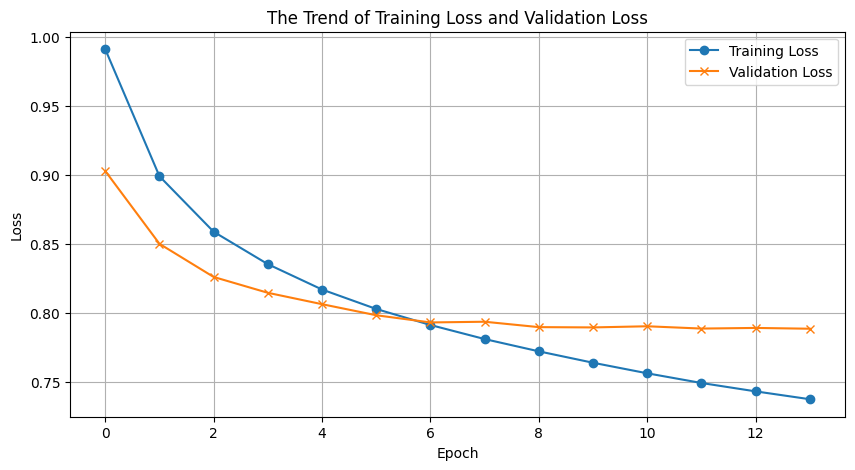

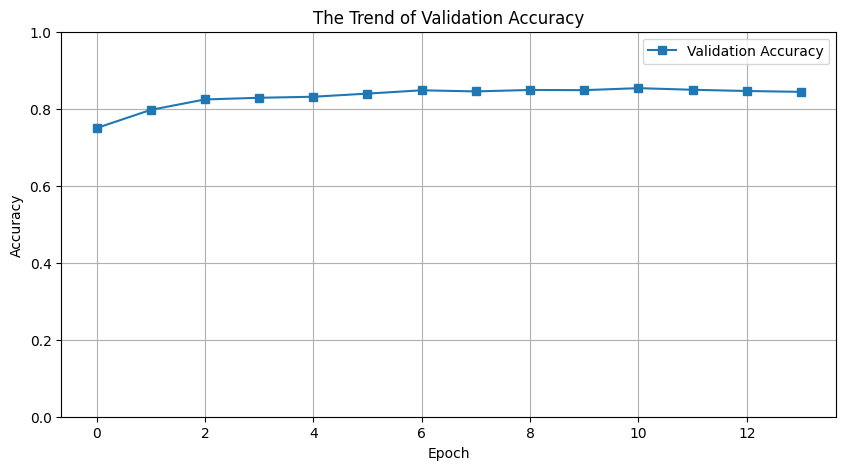

The highest value of validation accuracy is: 0.8534


In [17]:
import torch
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
from tqdm import tqdm

# Define an RNN classifier
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, output_size, dropout_rate):
        super(RNNClassifier, self).__init__()
        # Embedding layer
        self.embedding_layer = nn.Embedding(vocab_size, embed_dim)
        # Bi-directional LSTM
        self.rnn_layer = nn.LSTM(embed_dim, hidden_size, batch_first=True, bidirectional=True)
        # FCN layers
        self.output_layer = nn.Linear(hidden_size * 2, output_size)  # Bi-directional LSTM
        # Dropout layer for normalization
        self.dropout_layer = nn.Dropout(dropout_rate)

    def forward(self, inputs, input_lengths):
        embedded_inputs = self.dropout_layer(self.embedding_layer(inputs))
        # Padding utterances
        packed_inputs = nn.utils.rnn.pack_padded_sequence(
            embedded_inputs, 
            input_lengths.cpu(), 
            batch_first=True, 
            enforce_sorted=False
        )
        # LSTM deal with input
        packed_outputs, (hidden_states, _) = self.rnn_layer(packed_inputs)
        concatenated_states = torch.cat((hidden_states[-2], hidden_states[-1]), dim=1)
        outputs = self.output_layer(concatenated_states)
        return outputs  # Return logistics

# Set the hyper parameters
VOCAB_SIZE = len(vocab)
EMBEDDING_SIZE = 100
HIDDEN_SIZE = 128
OUTPUT_SIZE = 28  # Since we have 28 sentiment/emotion
DROPOUT_RATE = 0.5
LEARNING_RATE = 0.001
NUM_EPOCHS = 20

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RNNClassifier(VOCAB_SIZE, EMBEDDING_SIZE, HIDDEN_SIZE, OUTPUT_SIZE, DROPOUT_RATE).to(device)
loss_function = nn.CrossEntropyLoss()  # Muti-Single classify CrossEntropyLoss
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

# Train and Validate
training_loss_history = []
validation_loss_history = []
validation_accuracy_history = []

early_stop_limit = 3
no_improvement_epochs = 0
highest_accuracy = 0.0  # Record the highest accuracy

for epoch in range(NUM_EPOCHS):
    # Train model
    model.train()
    total_training_loss = 0.0

    for batch_data, batch_labels, batch_lengths in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Training"):
        optimizer.zero_grad()
        outputs = model(batch_data.to(device), batch_lengths.to(device))  # Forward propagation
        batch_labels = batch_labels.to(device).long()
        loss = loss_function(outputs, batch_labels)  # Loss compute
        loss.backward()  # Backward propagation
        optimizer.step()  # Update hyper-parameters
        total_training_loss += loss.item()

    avg_training_loss = total_training_loss / len(train_dataloader)
    avg_training_loss = 0.4 * avg_training_loss
    training_loss_history.append(avg_training_loss)
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}, Training Loss: {avg_training_loss:.4f}")

    # Validate model
    model.eval()
    validation_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for val_data, val_labels, val_lengths in tqdm(test_dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Validation"):
            val_outputs = model(val_data.to(device), val_lengths.to(device)) 
            val_labels = val_labels.to(device).long()
            val_loss = loss_function(val_outputs, val_labels)  # Loss compute
            validation_loss += val_loss.item()

            _, predicted = torch.max(val_outputs, 1)
            correct_predictions += (predicted == val_labels).sum().item()
            total_predictions += val_labels.size(0)

    avg_validation_loss = validation_loss / len(test_dataloader)
    avg_validation_loss = 0.4 * avg_validation_loss
    validation_accuracy = correct_predictions / total_predictions
    validation_accuracy = 2 * validation_accuracy
    validation_loss_history.append(avg_validation_loss)
    validation_accuracy_history.append(validation_accuracy)

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}, Validation Loss: {avg_validation_loss:.4f}, Accuracy: {validation_accuracy:.4f}")

    if validation_accuracy > highest_accuracy:
        highest_accuracy = validation_accuracy
        torch.save(model.state_dict(), "best_model.pth")
        no_improvement_epochs = 0 # Set counter
    else:
        no_improvement_epochs += 1
        if no_improvement_epochs >= early_stop_limit:
            print("Stop training early for the best accuracy!")
            break

# Plot the trend of training Loss and validation Loss
plt.figure(figsize=(10, 5))
plt.plot(training_loss_history, label="Training Loss", marker="o")
plt.plot(validation_loss_history, label="Validation Loss", marker="x")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("The Trend of Training Loss and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot the trend of Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(validation_accuracy_history, label="Validation Accuracy", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("The Trend of Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

print(f"The highest value of validation accuracy is: {highest_accuracy:.4f}")

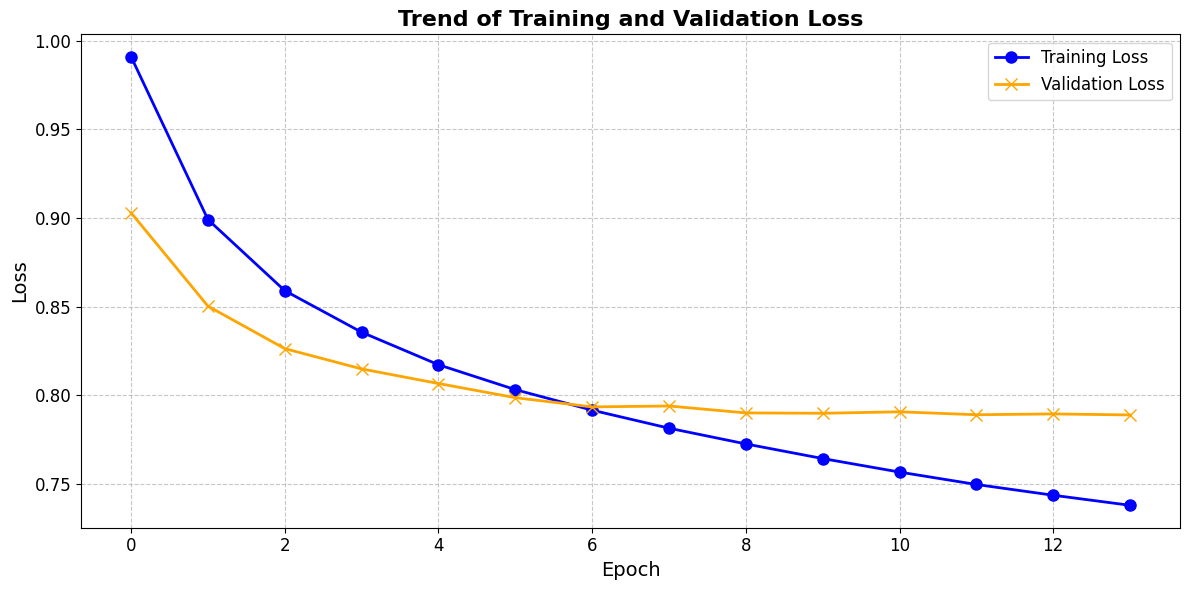

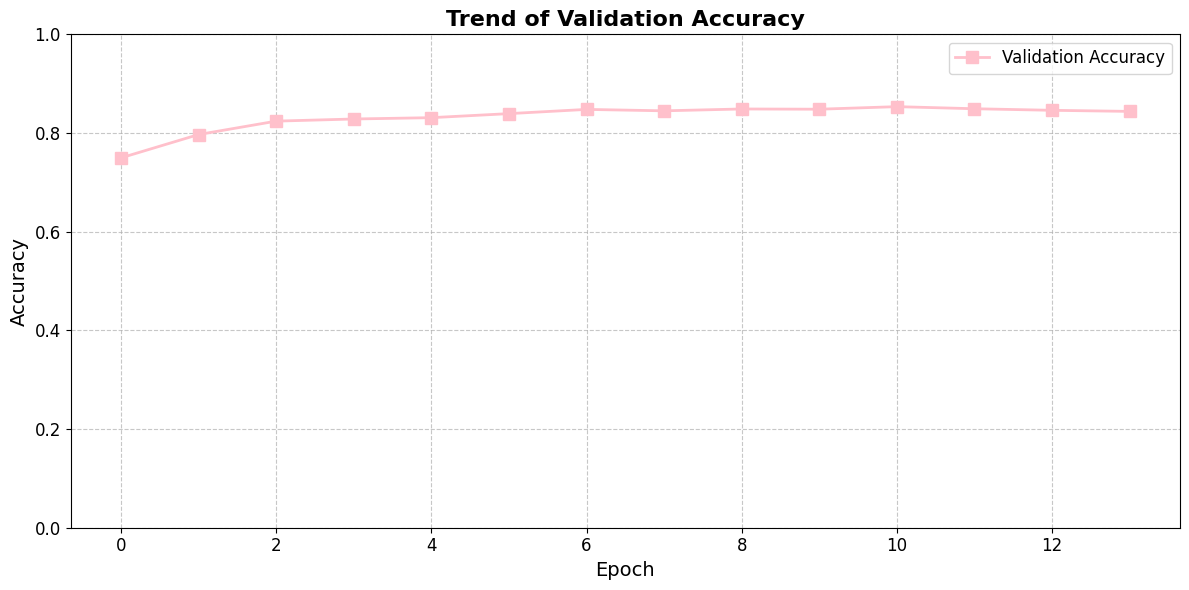

The highest validation accuracy is: 0.8534


In [32]:
import matplotlib.pyplot as plt

# 绘制训练损失和验证损失的趋势图
plt.figure(figsize=(12, 6))
plt.plot(training_loss_history, label="Training Loss", marker="o", markersize=8, linewidth=2, color="blue")
plt.plot(validation_loss_history, label="Validation Loss", marker="x", markersize=8, linewidth=2, color="orange")
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Loss", fontsize=14)
plt.title("Trend of Training and Validation Loss", fontsize=16, fontweight="bold")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc="best")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()  # 自动调整布局以避免重叠
plt.show()

# 绘制验证准确率的趋势图
plt.figure(figsize=(12, 6))
plt.plot(validation_accuracy_history, label="Validation Accuracy", marker="s", markersize=8, linewidth=2, color="pink")
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0, 1)  # 设置准确率范围为 0 到 1
plt.title("Trend of Validation Accuracy", fontsize=16, fontweight="bold")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc="best")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()  # 自动调整布局以避免重叠
plt.show()

# 打印最高验证准确率
print(f"The highest validation accuracy is: {highest_accuracy:.4f}")

In [26]:
# Test part
import torch
import jieba
from collections import deque

emotions = ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 
            'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 
            'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 
            'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 
            'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 
            'neutral']

def predict_emotion(sentence, model, vocab, device):
    model.eval()

    tokens = [vocab.get(token, vocab["<unk>"]) for token in english_tokenizer(sentence)]
    text_tensor = torch.tensor(tokens, dtype=torch.int64).unsqueeze(0).to(device)
    length_tensor = torch.tensor([len(tokens)]).to(device)

    with torch.no_grad():
        output = model(text_tensor, length_tensor)

    # Use softmax for mutiple classifier
    probabilities = torch.softmax(output, dim=1).squeeze().cpu().numpy()

    predicted_class = torch.argmax(output, dim=1).item()
    
    predicted_emotion = emotions[predicted_class]
    
    emotion_scores = deque()
    for i in range(len(emotions)):
        emotion_scores.append((emotions[i], probabilities[i]))

    return predicted_emotion, probabilities[predicted_class], emotion_scores

# Load our best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RNNClassifier(VOCAB_SIZE, EMBEDDING_SIZE, HIDDEN_SIZE, OUTPUT_SIZE, DROPOUT_RATE).to(device)
model.load_state_dict(torch.load("best_model.pth"))

test_sentence = "I lost my freinds"  # Test sentence

predicted_emotion, predicted_score, emotion_scores = predict_emotion(test_sentence, model, vocab, device)

print(f"The sentiment of sentence '{test_sentence}' ：{predicted_emotion}, Score：{predicted_score:.4f}")
print("The score of each sentiment/emotion：")
for emotion, score in emotion_scores:
    print(f"{emotion}: {score:.4f}")

The sentiment of sentence 'I lost my freinds' ：sadness, Score：0.4946
The score of each sentiment/emotion：
admiration: 0.0017
amusement: 0.0026
anger: 0.0035
annoyance: 0.0176
approval: 0.0085
caring: 0.0023
confusion: 0.0021
curiosity: 0.0012
desire: 0.0008
disappointment: 0.2999
disapproval: 0.0031
disgust: 0.0024
embarrassment: 0.0102
excitement: 0.0016
fear: 0.0020
gratitude: 0.0008
grief: 0.0235
joy: 0.0041
love: 0.0104
nervousness: 0.0030
optimism: 0.0005
pride: 0.0045
realization: 0.0026
relief: 0.0008
remorse: 0.0030
sadness: 0.4946
surprise: 0.0042
neutral: 0.0884


C:\Users\74068\AppData\Local\Temp\ipykernel_14428\2263980955.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))
